In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [11]:
np.random.seed(42)

# DATASET — Iris (4 variables continues, 150 obs.)
#    On masque aléatoirement 20% des valeurs → MCAR
#    (Missing Completely At Random)


iris = load_iris()
X_full = iris.data.astype(float)          
feature_names = iris.feature_names

# Masque MCAR : 20% de valeurs manquantes
mask = np.random.rand(*X_full.shape) < 0.20
X_missing = X_full.copy()
X_missing[mask] = np.nan

n_missing = mask.sum()
print(f"Dataset     : Iris — {X_full.shape[0]} obs., {X_full.shape[1]} variables")
print(f"Manquantes  : {n_missing} valeurs ({100*n_missing/X_full.size:.1f}%)\n")

Dataset     : Iris — 150 obs., 4 variables
Manquantes  : 135 valeurs (22.5%)



In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

em = IterativeImputer(
    max_iter=250,        
    tol=1e-4,
    random_state=42,
    verbose=0
)
X_em = em.fit_transform(X_missing)


In [13]:
#  MÉTRIQUES D'ÉVALUATION

y_true = X_full[mask]
y_em   = X_em[mask]

def rmse(a, b): return root_mean_squared_error(a, b)
def mae(a, b):  return mean_absolute_error(a, b)

results = pd.DataFrame({
    'RMSE':     [rmse(y_true, y_em)],
    'MAE':      [mae(y_true, y_em)],
})
print("Métriques globales")
print(results.round(4).to_string(index=False))

print("\n RMSE par variable")
X_mean_full = SimpleImputer(strategy='mean').fit_transform(X_missing)
rmse_cols = pd.DataFrame({
    'Variable': feature_names,
    'EM':      [rmse(X_full[mask[:,j], j], X_em[mask[:,j], j])
                if mask[:,j].sum() > 0 else np.nan for j in range(4)],
    'Moyenne': [rmse(X_full[mask[:,j], j], X_mean_full[mask[:,j], j])
                if mask[:,j].sum() > 0 else np.nan for j in range(4)],
})
print(rmse_cols.round(4).to_string(index=False))



Métriques globales
  RMSE    MAE
0.3706 0.2707

 RMSE par variable
         Variable     EM  Moyenne
sepal length (cm) 0.3319   0.8355
 sepal width (cm) 0.2998   0.3687
petal length (cm) 0.4876   1.7613
 petal width (cm) 0.3113   0.7599


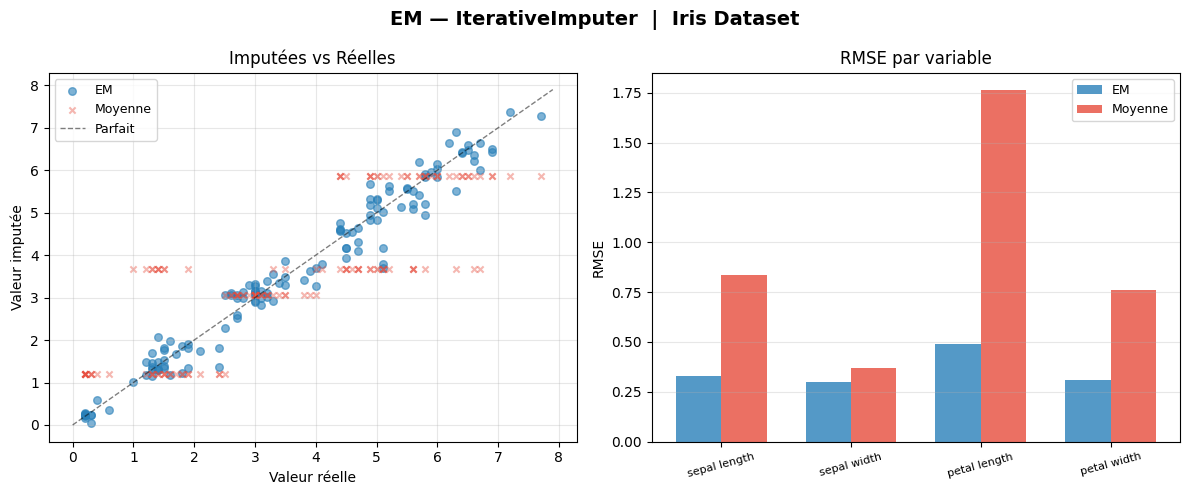

In [ ]:
# VISUALISATIONS


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("EM — IterativeImputer  |  Iris Dataset", fontsize=14, fontweight='bold')

# Imputées vs réelles
ax = axes[0]
ax.scatter(y_true, y_em,   alpha=0.6, color='#2980B9', s=30, label='EM')
ax.scatter(y_true, y_mean, alpha=0.4, color='#E74C3C', s=20, label='Moyenne', marker='x')
lim = [y_true.min() - 0.2, y_true.max() + 0.2]
ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='Parfait')
ax.set(xlabel="Valeur réelle", ylabel="Valeur imputée", title="Imputées vs Réelles")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# RMSE par variable
ax = axes[1]
x_pos = np.arange(len(feature_names))
w = 0.35
ax.bar(x_pos - w/2, rmse_cols['EM'],     width=w, label='EM',     color='#2980B9', alpha=0.8)
ax.bar(x_pos + w/2, rmse_cols['Moyenne'], width=w, label='Moyenne', color='#E74C3C', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace(' (cm)', '') for f in feature_names], rotation=15, fontsize=8)
ax.set(ylabel="RMSE", title="RMSE par variable")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
